# Sales Forecasting Using ARIMA

This project forecasts monthly sales using time series modeling techniques. The goal is to build a statistically sound and interpretable forecasting model suitable for business planning.

## Project Overview
This project focuses on forecasting retail sales using time series modeling techniques.
The objective is to build a statistically sound and interpretable forecasting model that can support short-term business planning and demand estimation.
This analysis follows a structured workflow:
- Data aggregation and visualization
- Stationarity testing
- Model estimation using ARIMA
- Diagonistic Checking
- Forecast evaluation using error metrics

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_percentage_error

## 2. Load Dataset

In [29]:
df = pd.read_csv("supermarket sales data.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df = df.sort_values('Order Date')
df.set_index('Order Date', inplace=True)


## 3. Monthly Aggregation

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20420\4060745670.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Sales'].resample('M').sum()


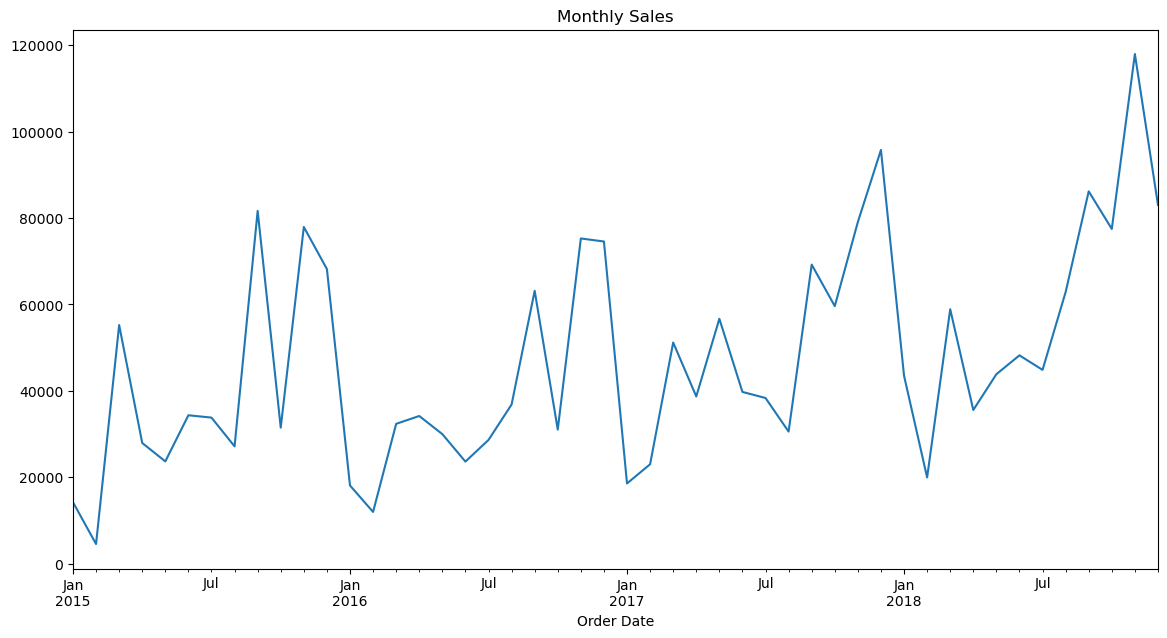

In [30]:
monthly_sales = df['Sales'].resample('M').sum()
plt.figure(figsize=(14, 7))
monthly_sales.plot(title='Monthly Sales')
plt.show()


## Exploratory Data Analysis

**Observations:**
The monthly sales series shows an overall upward trend with noticeable fluctuations.
This visual pattern suggests potential non-stationarity due to a changing mean over time.
A formal stationarity test is conducted in the next section to confirm this.


## 4. Train-Test Split

In [20]:
train = monthly_sales[:-6]
test = monthly_sales[-6:]
len(train), len(test)

(42, 6)

## 5. Log Transformation

In [21]:
train_log = np.log(train)
test_log = np.log(test)

## 6. Stationarity Check (ADF Test)

In [22]:
adf_result = adfuller(train_log)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

ADF Statistic: -5.717045270896062
p-value: 7.081450812149922e-07


## Stationarity Test (ADF)

The Augmented Dickey-Fuller (ADF) test is applied to assess whether the
log-transformed monthly sales series is stationary.

**Result Interpretation:**
- The ADF test statistic is −5.72
- The p-value is significantly less than 0.05

Since the p-value is below the 5% significance level, the null hypothesis
of a unit root is rejected. This indicates that the log-transformed sales
series is stationary.

Therefore, the transformed data is suitable for ARIMA modeling.


## 7. Model Estimation

In [23]:
model = SARIMAX(
    train_log,
    order=(1,1,0),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                   42
Model:               SARIMAX(1, 1, 0)   Log Likelihood                 -40.108
Date:                Thu, 29 Jan 2026   AIC                             84.216
Time:                        23:05:14   BIC                             87.594
Sample:                    01-31-2015   HQIC                            85.438
                         - 06-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4082      0.154     -2.658      0.008      -0.709      -0.107
sigma2         0.4350      0.091      4.767      0.000       0.256       0.614
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 1.85
Prob(Q):                              0.81   Prob(JB):                         0.40
Heteroskedasticity (H):               0.33   Skew:                             0.04
Prob(H) (two-sided):                  0.05   Kurtosis:                         4.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Model Specification and Interpretation

An ARIMA(1,1,0) model is selected based on diagnostic checks and the
characteristics of the differenced sales series.

**Key Insights:**
- The AR(1) coefficient is statistically significant (p < 0.01)
- The negative AR(1) coefficient suggests short-term mean reversion in sales changes,
  where unusually high or low growth tends to be followed by partial correction
- This indicates the presence of short-term dependence in the differenced sales series



## 8. Residual Diagnostics

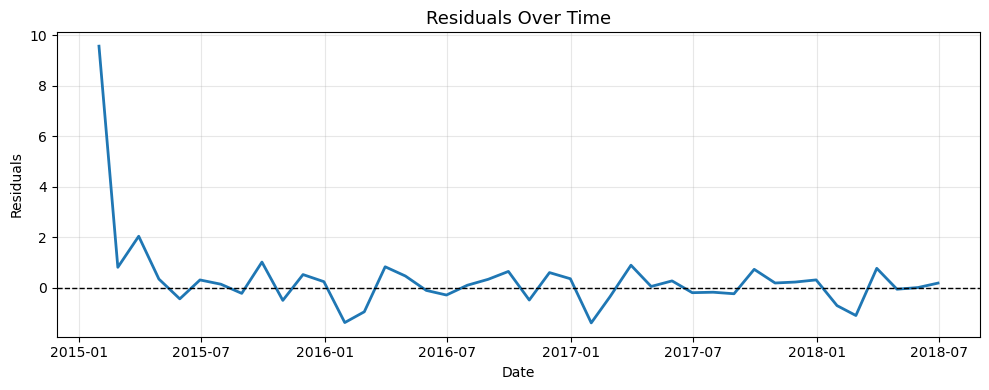

<Figure size 1200x400 with 0 Axes>

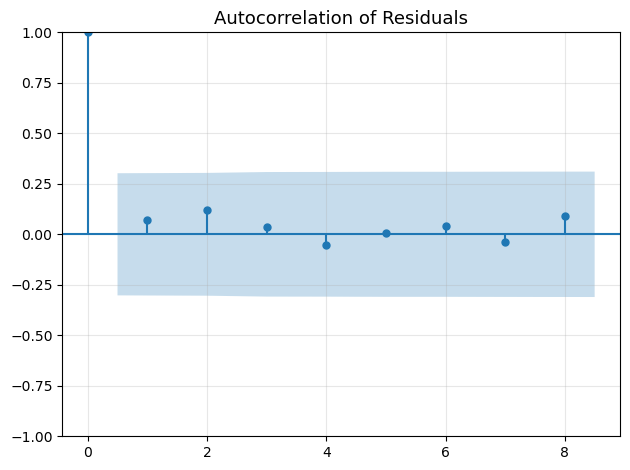

In [24]:
residuals = results.resid 

plt.figure(figsize=(10, 4))
plt.plot(residuals, linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Residuals Over Time', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plot_acf(residuals, lags=8)
plt.title('Autocorrelation of Residuals', fontsize=13)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Residual Analysis

**Observation:**
The residuals are centered around zero and show no systematic trend over time,
indicating that the model has captured the main structure of the sales series.

Apart from an initial larger residual, the remaining errors appear randomly
distributed with relatively stable variance. This suggests that the ARIMA model
provides an adequate fit, though some short-term volatility remains, which is
expected in retail sales data.

## Autocorrelation Diagnostics

The autocorrelation function (ACF) of the residuals shows that all lags
lie within the 95% confidence bounds.

**Interpretation:**
There is no evidence of statistically significant remaining autocorrelation,
indicating that the model has adequately captured the temporal dependence
in the data.



## 9. Forecasting

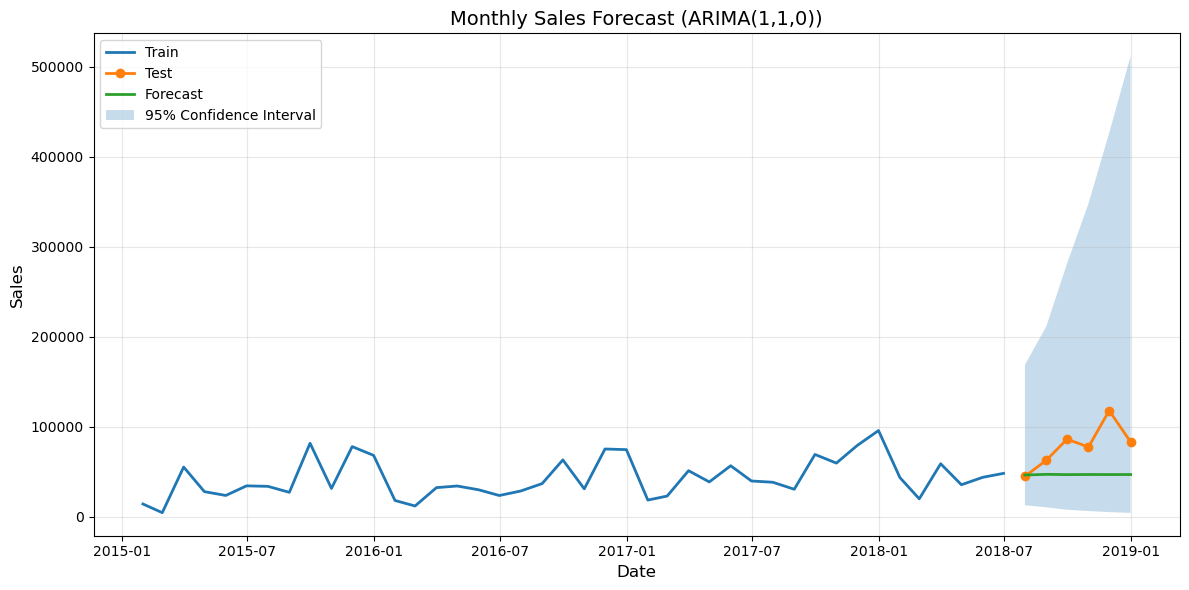

In [13]:
forecast = results.get_forecast(steps=6)
forecast_mean_log = forecast.predicted_mean
forecast_ci_log = forecast.conf_int()

forecast_mean = np.exp(forecast_mean_log)
forecast_lower = np.exp(forecast_ci_log.iloc[:, 0])
forecast_upper = np.exp(forecast_ci_log.iloc[:, 1])

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train', linewidth=2)
plt.plot(test.index, test, label='Test', linewidth=2, marker='o')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', linewidth=2)

plt.fill_between(
    forecast_mean.index,
    forecast_lower,
    forecast_upper,
    alpha=0.25,
    label='95% Confidence Interval'
)

plt.title('Monthly Sales Forecast (ARIMA(1,1,0))', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sales Forecast Interpretation

The point forecast remains relatively stable, reflecting the model’s
expectation that recent changes in sales will not persist strongly
into the future.

The confidence intervals widen substantially as the forecast horizon
extends, indicating increasing uncertainty in long-term predictions.
This behavior is typical in ARIMA based forecasting and suggests that
the model is more reliable for short-term planning and scenario analysis.


## 10. Model Evaluation

In [14]:
forecast_test = forecast_mean.iloc[:len(test)]
mape = mean_absolute_percentage_error(test, forecast_test)
print('MAPE:', round(mape*100, 2), '%')

MAPE: 36.23 %


In [15]:
def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100

smape_value = smape(test, forecast_mean[:len(test)])
print(f"sMAPE: {smape_value:.2f} %")


sMAPE: 47.03 %


## Forecast Accuracy Evaluation

- **MAPE** measures the average percentage error relative to actual sales
- **sMAPE** provides a symmetric error measure that penalizes both over-
  and under-forecasting

The forecast errors indicate moderate predictive performance. Given the
high volatility of retail sales and the absence of external factors such
as promotions or seasonality indicators, this level of accuracy is
considered acceptable for short-term planning and trend analysis.


## Conclusion

This project demonstrates the application of ARIMA-based time series modeling
to forecast monthly retail sales.

The model captures short-term sales dynamics and provides interpretable
forecasts that can support business planning and trend analysis.
As forecast uncertainty increases with the prediction horizon, the model
is most suitable for short-term demand estimation rather than long-term
precise forecasting.

Future improvements could include incorporating seasonal effects,
external variables (e.g., promotions or holidays), or longer historical data
to enhance predictive accuracy.
